![gif](dog.gif)

In [2]:
import requests
from bs4 import BeautifulSoup
import os
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By 
from webdriver_manager.chrome import ChromeDriverManager
from fake_useragent import UserAgent
import time
import random
from tqdm import tqdm
from datetime import date, timedelta
import pandas as pd
import re

## Собираем корпус данных

В качестве материала для исследования был выбран корпус новостных текстов российских СМИ (**РИА Новости** и **Лента.ру**) за период 2018–2026 гг., отобранных по наличию упоминаний собак с помощью редакторских тегов или поиска по ключевому слову.

### Парсинг сайтов РИА и Лента.ру
#### Собираем ссылки на новости
> Для парсинга материалов РИА используется Selenium, поскольку контент загружается динамически и недоступен при статическом HTTP-запросе

In [288]:
#настройка опций Chrome для конспирации и стабильности + настройка драйвера. Взяла из Хабра и немного адаптировала.
def open_browser():
    '''Открывает страницу поисковика'''
    user_agent = UserAgent().chrome
    options = Options()
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920,1080")
    options.add_argument(f"user-agent={user_agent}")

    service = Service(ChromeDriverManager().install())
    driver = webdriver.Chrome(service=service, options=options)
    return driver

In [12]:
driver = open_browser()

> Сначала собираем ссылки на материалы с редакторским тегом "собаки"

In [ ]:
url = "https://ria.ru/keyword_sobaki/" 
driver.get(url)
time.sleep(4)

#сайт динамический, но на нем надо один раз нажать кнопку 'показать еще', далее сайт прогружается автоматически при скролле
button = driver.find_element(By.CSS_SELECTOR, "div.list-more")
driver.execute_script("arguments[0].click();", button)
time.sleep(4) #ждем прогрузку материалов

for i in tqdm(range(30)):
    headers={'User-Agent': UserAgent().chrome}
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep((random.uniform(2.0, 4.0)))
    html = driver.page_source
    print("Длина страницы:", len(html)) #проверка работы скролла

    if "https://ria.ru/2017" in html:
        print("Начались статьи от 2017 года, останавливаемся")
        break

driver.quit()

soup = BeautifulSoup(html, "html.parser")

links_ria_tag_sobaki = set()
for link in soup.find_all('a'):
    href = link.get('href')

    if href is None: #проверка на None
        continue 

    if link.get('href').startswith('https://ria.ru/20'):
        links_ria_tag_sobaki.add(link.get('href'))
time.sleep(random.uniform(2.0, 4.0))

print(f"Собрано {len(links_ria_tag_sobaki)} ссылок")
for l in list(links_ria_tag_sobaki)[:10]:
    print(l)

  3%|▎         | 1/30 [00:02<01:15,  2.60s/it]

Длина страницы: 941560


  7%|▋         | 2/30 [00:05<01:14,  2.68s/it]

Длина страницы: 1033284


 10%|█         | 3/30 [00:08<01:21,  3.01s/it]

...

 50%|█████     | 15/30 [00:43<00:41,  2.79s/it]

Длина страницы: 2120546


 50%|█████     | 15/30 [00:47<00:47,  3.14s/it]

Длина страницы: 2190098
Начались статьи от 2017 года, останавливаемся


Собрано 359 ссылок
https://ria.ru/20220724/sobaka-1804577812.html
https://ria.ru/20211004/otravlenie-1753048989.html
https://ria.ru/20210226/sobaki-1599028840.html
https://ria.ru/20241209/lay-1769491791.html
https://ria.ru/20241118/scmp-1984316664.html
https://ria.ru/20251205/veterinary-2059923755.html
https://ria.ru/20240709/festival-1958511895.html
https://ria.ru/20220204/sobaki-1771093490.html
https://ria.ru/20230216/schenok-1852382054.html
https://ria.ru/20211125/priyuty-1760643996.html


In [5]:
with open("ria_sobaki_links.txt", "w", encoding="utf-8") as f:
    for link in links_ria_tag_sobaki:
        f.write(link + "\n")

> Теперь ищем публикации по ключевому слову. Иногда у статьи о собаках не проставлены теги, иногда собаки не являются основной темой статьи, но могут упоминаться в значимом контексте. 

> РИА ограничивает количество прогружаемых материалов, поэтому при запросе крупных периодов часть публикаций может быть потеряна. Для полноты корпуса парсинг выполняется по каждому дню каждого года.

In [8]:
from datetime import date, timedelta

#c кодом этой функции частично помог чат gpt
def everyday_links_collector(start,end):
    '''Возвращает список url для каждого дня в диапазоне start..end'''
    days = (end - start).days + 1  #чтобы включить последний день
    
    everyday_links = []

    for i in range(days):
        cur = start + timedelta(days=i)  # текущий день
        day_str = cur.isoformat()  # преобразуем в YYYY-MM-DD
        url = (f'https://ria.ru/services/search/getmore/?query=собак&date_from={day_str}&date_to={day_str}')
        everyday_links.append(url)
    return everyday_links

def ria_collected_links(links):
    '''Cоздает файл, а затем дополняет его собранными ссылками'''
    with open('ria_search_sobak.txt', "a", encoding="utf-8") as f:
        for l in sorted(links):
            f.write(l + "\n")

In [9]:
#парсер для каждого года
def parse_ria_year(year, end_day=None):
    start = date(year, 1, 1)
    end = date(year, 12, 31)
    if end_day:
        end = end_day
    
    everyday_links = everyday_links_collector(start, end)
    print(f"\nГод {year}, дней: {len(everyday_links)}")
    
    ria_query_sobak_links = set() 
    
    for d_link in tqdm(everyday_links):
        headers={'User-Agent': UserAgent().chrome} 
        d_link_html = requests.get(d_link, headers=headers)
        time.sleep(random.uniform(2.0, 4.0))
        
        if d_link_html.status_code !=200:
          continue
        
        soup = BeautifulSoup(d_link_html.text, "xml")
        
        for article_link in soup.find_all('a'):
            href = article_link.get('href')
            
            if href is None:
             continue
            
            if article_link.get('href').startswith('https://ria.ru/20'):
               ria_query_sobak_links.add(article_link.get('href'))
               
    ria_collected_links(ria_query_sobak_links)
    print(f"Всего статей за {year}: {len(ria_query_sobak_links)}")

In [300]:
parse_ria_year(2018)


Год 2018, дней: 365


100%|██████████| 365/365 [24:09<00:00,  3.97s/it]

Всего статей за 2018: 1119


In [301]:
parse_ria_year(2019)


Год 2019, дней: 365


100%|██████████| 365/365 [23:14<00:00,  3.82s/it]

Всего статей за 2019: 965


In [302]:
parse_ria_year(2020)


Год 2020, дней: 366


100%|██████████| 366/366 [23:48<00:00,  3.90s/it]

Всего статей за 2020: 1142


In [4]:
parse_ria_year(2021)


Год 2021, дней: 365


100%|██████████| 365/365 [23:22<00:00,  3.84s/it]

Всего статей за 2021: 1061


In [10]:
parse_ria_year(2022)


Год 2022, дней: 365


  0%|          | 0/365 [00:00<?, ?it/s]

100%|██████████| 365/365 [25:52:59<00:00, 255.29s/it]     

Всего статей за 2022: 671


In [11]:
parse_ria_year(2023)


Год 2023, дней: 365


100%|██████████| 365/365 [20:52<00:00,  3.43s/it]

Всего статей за 2023: 762


In [12]:
parse_ria_year(2024)


Год 2024, дней: 366


100%|██████████| 366/366 [21:13<00:00,  3.48s/it]

Всего статей за 2024: 842


In [13]:
parse_ria_year(2025)


Год 2025, дней: 365


100%|██████████| 365/365 [21:30<00:00,  3.54s/it]

Всего статей за 2025: 912


In [14]:
parse_ria_year(2026, end_day=date(2026, 1, 20))


Год 2026, дней: 20


100%|██████████| 20/20 [01:11<00:00,  3.59s/it]

Всего статей за 2026: 33


In [17]:
#Объединяем два файла в один и убираем дубликаты
ria_all_links = set()

for file in ["ria_sobaki_links.txt", "ria_search_sobak.txt"]:
    with open(file, encoding="utf-8") as f:
        for line in f:
            ria_all_links.add(line.strip())

with open("ria_links.txt", "w", encoding="utf-8") as f:
    for link in sorted(ria_all_links):
        f.write(link + "\n")

print("Всего уникальных ссылок:", len(ria_all_links))

Всего уникальных ссылок: 7562


> Из-за отсутствия на Lenta.ru фильтрации по тегам или темам отбор материалов осуществляется с помощью поиска по ключевому слову «собак». Однако параметры запроса не отображаются напрямую в адресной строке браузера.

> Для получения шаблона запроса был изучен код страницы: через вкладку *Network* были обнаружены XHR-запросы, отправляемые при загрузке поисковой выдачи. Параметр `offset` позволил получать полную выдачу программно, без имитации скроллинга или нажатия кнопки «Показать ещё» с помощью Selenium.

> Lenta.ru не имеет ограничения на количество материалов, подгружаемых при прокрутке, поэтому сбор ссылок возможен крупными временными интервалами. Тем не менее, для повышения надёжности и контроля процесса парсинга данные собираются по годам, а не одним запросом за весь период с 2018 по 2026 годов. Такой подход позволяет убедиться, что все ссылки за каждый год были корректно загружены и сохранены.

In [2]:
def lenta_collected_links(links):
    '''Cоздает файл, а затем дополняет его собранными ссылками'''
    with open('lenta_links.txt', "a", encoding="utf-8") as f:
        for l in sorted(links):
            f.write(l + "\n")

In [3]:
def parse_lenta_period(date_from, date_to):
    lenta_article_links = set()
    offset = 0
    step = 10 #берем шаг 10, так как одна страничка до кнопки "показать еще" показывает 10 статей

    headers={"User-Agent": "Mozilla/5.0", "Accept": "application/json"}
    progress=tqdm(desc = "Сбор статей", unit="artcl") 
    while True:
        url = (
            "https://lenta.ru/search/v2/process"
            f"?query=собак"
            f"&from={offset}"
            f"&size={step}"
            f"&sort=2"
            f"&title_only=0"
            f"&domain=1"
            f"&modified,format=yyyy-MM-dd"
            f"&modified,from={date_from}"
            f"&modified,to={date_to}"
        )
        
    
        r = requests.get(url, headers=headers)
        data = r.json()
        results = data.get("matches", [])
        time.sleep(random.uniform(2.0, 4.0))

        if not results:
            break

        for i in results:
            href = i.get("url")
            if href and ("/news/" in href or "/articles/" in href):
                lenta_article_links.add(href)
                progress.update(1)

        offset += step
        time.sleep(0.5)
    
    lenta_collected_links(lenta_article_links)
    print(f"Всего статей за период: {len(lenta_article_links)}")

In [6]:
parse_lenta_period("2018-01-01", "2018-12-31")

Сбор статей: 728artcl [04:36,  2.63artcl/s]

Всего статей за период: 728


In [7]:
parse_lenta_period("2019-01-01", "2019-12-31")

Сбор статей: 961artcl [06:31,  2.45artcl/s]

Всего статей за период: 961


In [8]:
parse_lenta_period("2020-01-01", "2020-12-31")

Сбор статей: 1095artcl [07:09,  2.55artcl/s]

Всего статей за период: 1095


In [9]:
parse_lenta_period("2021-01-01", "2021-12-31")

Сбор статей: 1159artcl [06:48,  2.84artcl/s]

Всего статей за период: 1159


In [10]:
parse_lenta_period("2022-01-01", "2022-12-31")

Сбор статей: 1198artcl [07:03,  2.83artcl/s]

Всего статей за период: 1198


In [11]:
parse_lenta_period("2023-01-01", "2023-12-31")

Сбор статей: 1297artcl [07:28,  2.89artcl/s]

Всего статей за период: 1297


In [4]:
parse_lenta_period("2024-01-01", "2024-12-31")

Сбор статей: 0artcl [00:00, ?artcl/s]

Сбор статей: 1569artcl [10:34,  2.47artcl/s]

Всего статей за период: 1569


In [5]:
parse_lenta_period("2025-01-01", "2025-12-31")

Сбор статей: 1666artcl [10:57,  2.53artcl/s]

Всего статей за период: 1666


In [6]:
parse_lenta_period("2026-01-01", "2026-01-22")

Сбор статей: 67artcl [00:30,  2.16artcl/s]

Всего статей за период: 67


#### Извлечение содержимого

После сбора ссылок выполняется загрузка HTML и извлечение ключевых атрибутов публикаций (дата, ссылка, заголовок, текст). Полученные данные приводятся к табличному виду и используются для дальнейшего анализа.

In [3]:
ria_links = []
with open("ria_links.txt", "r", encoding="utf-8") as f:
    for line in f:
        ria_links.append(line.strip())

print(ria_links[:15])


['https://ria.ru/20180101/1512049297.html', 'https://ria.ru/20180101/1512049793.html', 'https://ria.ru/20180102/1512077987.html', 'https://ria.ru/20180102/1512079536.html', 'https://ria.ru/20180103/1130267475.html', 'https://ria.ru/20180103/1130785105.html', 'https://ria.ru/20180103/1512122871.html', 'https://ria.ru/20180106/1512187714.html', 'https://ria.ru/20180106/1512189510.html', 'https://ria.ru/20180106/1512194926.html', 'https://ria.ru/20180106/1512201080.html', 'https://ria.ru/20180106/1512203539.html', 'https://ria.ru/20180106/1512205155.html', 'https://ria.ru/20180108/1130627535.html', 'https://ria.ru/20180108/1512246761.html']


In [17]:
def GetNews(url0):
  try:
    page0 = session.get(url0, timeout=15)
    if page0.status_code != 200:
       return None
    
    soup0 = BeautifulSoup(page0.text, features="html.parser")
    
    title_tag = soup0.find('meta', {'property' : 'og:title'})
    if not title_tag:
       return None
    
    title = title_tag['content']
    if not title:
       return None
    
    date_tag = soup0.find('div', class_='article__info-date')
    if not date_tag:
       return None
    
    date = date_tag.find('a').text
    if not date:
       return None
    
    link_url_tag = soup0.find('meta', {'property' : 'og:url'})
    if not link_url_tag:
       return None
    
    link_url = link_url_tag['content']
    if not link_url:
       return None
    
    texts = soup0.find_all('div', class_='article__text')
    if not texts:
      return None
    
    text = [i.text for i in texts]
    final_text = ' '.join(text)
    final_text = final_text.replace('\xa0', ' ')
    
    return (url0, date, title, final_text)
  
  except Exception:
     return None

In [18]:
ria_news = []
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

for i in tqdm(range(len(ria_links))):
  new = GetNews(ria_links[i])
  if new:
    ria_news.append(new)
  time.sleep(random.uniform(1.0, 2.0))

ria_news[:10]

100%|██████████| 7168/7168 [4:16:31<00:00,  2.15s/it]  


[('https://ria.ru/20180101/1512049297.html',
  '00:51 01.01.2018',
  'Украина продлила запрет на ввоз ряда российских товаров',
  '\nКИЕВ, 1 янв — РИА Новости. Решение правительства Украины о продлении до 2019 года действия эмбарго на ряд товаров из РФ вступило в понедельник в силу. Также с 1 января на год продлена отмена действия зоны свободной торговли (ЗСТ) с РФ.\nНесмотря на взаимные ограничения в торговле, товарооборот между странами в последний год снова начал расти.\nСписок запретов увеличивается\nПравительство Украины 20 декабря 2017 года приняло решение о продлении действия эмбарго, введенного в 2016 году, еще на год, а также расширило перечень российских товаров, которые запрещены для ввоза в страну. В утвержденный ранее перечень теперь включены дополнительно такие позиции, как полиэтилен с удельным весом 0,94 или больше, поливинилхлорид, не смешанный с другими веществами, сульфат аммония, смесь нитрата аммония с карбонатом кальция или другими неорганическими веществами, не я

In [19]:
print(len(ria_news))

6975


In [ ]:
df = pd.DataFrame(ria_news)
df.columns = ['Ссылка', 'Дата', 'Заголовок', 'Текст']
df.to_csv('ria_news.csv', index=False, encoding='utf-8-sig')

In [20]:
lenta_links = []
with open("lenta_links.txt", "r", encoding="utf-8") as f:
    for line in f:
        lenta_links.append(line.strip())

print(lenta_links[:15])

['https://lenta.ru/articles/2018/01/04/dnr/', 'https://lenta.ru/articles/2018/01/04/notsofun/', 'https://lenta.ru/articles/2018/01/06/dobro/', 'https://lenta.ru/articles/2018/01/07/volonter/', 'https://lenta.ru/articles/2018/01/12/whales/', 'https://lenta.ru/articles/2018/01/15/askazka/', 'https://lenta.ru/articles/2018/01/18/sihh2018/', 'https://lenta.ru/articles/2018/01/21/italy/', 'https://lenta.ru/articles/2018/01/25/ss/', 'https://lenta.ru/articles/2018/01/26/doroga/', 'https://lenta.ru/articles/2018/01/26/monkey/', 'https://lenta.ru/articles/2018/01/26/volki/', 'https://lenta.ru/articles/2018/01/28/eco/', 'https://lenta.ru/articles/2018/01/31/kanaldoverie/', 'https://lenta.ru/articles/2018/02/02/torch/']


In [15]:
def GetLentaNews(url0):
    try:
        page0 = session.get(url0, timeout=15)
        if page0.status_code != 200:
            return None

        soup0 = BeautifulSoup(page0.text, features="html.parser")

        title_tag = soup0.find("meta", property="og:title")
        if not title_tag:
            return None
        title = title_tag['content']

        date_tag = soup0.find("a", class_="topic-header__time")
        if not date_tag:
            return None
        date = date_tag.text

        link_url_tag = soup0.find('meta', {'property' : 'og:url'})
        if not link_url_tag:
            return None
        
        link_url = link_url_tag['content']
        if not link_url:
            return None

        texts = soup0.find_all("p", class_="topic-body__content-text")
        if not texts:
            return None

        text = [i.text for i in texts]
        final_text = ' '.join(text)
        final_text = final_text.replace('\xa0', ' ')
        
        return (link_url, date, title, final_text)
    except Exception:
        return None


In [23]:
session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

with open("lenta_news.csv", "a", encoding="utf-8") as f:
  f.write('link_url, date, title, final_text\n')

  for i in tqdm(range(len(lenta_links))):
    new = GetLentaNews(lenta_links[i])
    if new:
        link_url, date, title, final_text = new
        title = title.replace("\n", " ").replace(";", ",")
        final_text = final_text.replace("\n", " ").replace(";", ",")

        line = f"{link_url};{date};{title};{final_text}\n"
        f.write(line)
    time.sleep(random.uniform(1.0, 2.0))
  


100%|██████████| 9740/9740 [5:13:22<00:00,  1.93s/it]  


### Предварительная оценка корпуса

Для предварительной оценки корпуса был проведён анализ распределения длин текстов, который показал сопоставимость новостных материалов в источниках РИА Новости и Лента.ру. В качестве фильтрации были исключены сверхкороткие сообщения длиной менее 60 слов, соответствующие кратким новостным заметкам из 1–2 предложений и не содержащие достаточного лингвистического контекста для анализа образа.

In [18]:
df_lenta = pd.read_csv("lenta_news.csv", sep=';', encoding='utf-8')
df_lenta  = df_lenta.rename(columns={
    'link_url':'Cсылка',
    'date':'Дата',
    'title':'Заголовок',
    'final_text':'Текст'
    })
df_lenta.head()

,Cсылка,Дата,Заголовок,Текст
0,https://lenta.ru/articles/2018/01/04/dnr/,"00:05, 4 января 2018","«Мы устали, мы никому не нужны» В ДНР проклина...",Четвертый год на востоке Украины идет война. З...
1,https://lenta.ru/articles/2018/01/04/notsofun/,"00:06, 4 января 2018",Хорошо забытое старое Мы писали для вас взрывн...,За 2017 год в сети произошло множество значимы...
2,https://lenta.ru/articles/2018/01/06/dobro/,"00:03, 6 января 2018","Тоже люди Что бывает, когда у преступников про...","Принято считать, что преступники — люди безнад..."
3,https://lenta.ru/articles/2018/01/07/volonter/,"00:01, 7 января 2018",«Потом может и не быть» Почему люди становятся...,В России 2018-й объявлен Годом добровольца. Ещ...
4,https://lenta.ru/articles/2018/01/12/whales/,"15:32, 12 января 2018","С гарпуном на Левиафана Люди убивают китов, чт...",Краснокнижных серых китов на территории России...


In [19]:
df_ria = pd.read_csv("ria_news.csv", sep=',', encoding='utf-8')
df_ria.head()

,Ссылка,Дата,Заголовок,Текст
0,https://ria.ru/20180101/1512049297.html,00:51 01.01.2018,Украина продлила запрет на ввоз ряда российски...,"\nКИЕВ, 1 янв — РИА Новости. Решение правитель..."
1,https://ria.ru/20180101/1512049793.html,01:16 01.01.2018,На набережной Геленджика пройдет антиалкогольн...,"КРАСНОДАР, 1 янв — РИА Новости. Антиалкогольна..."
2,https://ria.ru/20180102/1512077987.html,09:28 02.01.2018,Спа и пиво с картошкой: как в Бельгии балуют с...,"БРЮССЕЛЬ, 2 янв – РИА Новости, Александр Шишло..."
3,https://ria.ru/20180102/1512079536.html,10:41 02.01.2018,Минобороны поздравило россиян с Новым годом ви...,"МОСКВА, 2 янв — РИА Новости. Министерство обор..."
4,https://ria.ru/20180103/1130267475.html,10:00 03.01.2018,Хоккеист Руслан Берников: в Корее меня называю...,"Среди профессиональных хоккеистов всего мира, ..."


In [20]:
df_ria['Длина текста'] = df_ria['Текст'].str.split().str.len()
df_ria.head()

,Ссылка,Дата,Заголовок,Текст,Длина текста
0,https://ria.ru/20180101/1512049297.html,00:51 01.01.2018,Украина продлила запрет на ввоз ряда российски...,"\nКИЕВ, 1 янв — РИА Новости. Решение правитель...",863.0
1,https://ria.ru/20180101/1512049793.html,01:16 01.01.2018,На набережной Геленджика пройдет антиалкогольн...,"КРАСНОДАР, 1 янв — РИА Новости. Антиалкогольна...",154.0
2,https://ria.ru/20180102/1512077987.html,09:28 02.01.2018,Спа и пиво с картошкой: как в Бельгии балуют с...,"БРЮССЕЛЬ, 2 янв – РИА Новости, Александр Шишло...",1042.0
3,https://ria.ru/20180102/1512079536.html,10:41 02.01.2018,Минобороны поздравило россиян с Новым годом ви...,"МОСКВА, 2 янв — РИА Новости. Министерство обор...",80.0
4,https://ria.ru/20180103/1130267475.html,10:00 03.01.2018,Хоккеист Руслан Берников: в Корее меня называю...,"Среди профессиональных хоккеистов всего мира, ...",2223.0


In [21]:
df_ria['Длина текста'].describe()

count     6973.000000
mean       379.013194
std        565.118346
min         11.000000
25%        128.000000
50%        196.000000
75%        372.000000
max      10697.000000
Name: Длина текста, dtype: float64

In [22]:
short = df_ria[df_ria['Длина текста'] < 60]
long = df_ria[df_ria['Длина текста'] >= 60]

print("Короткие заметки:", len(short))
print("Полноценные статьи:", len(long))

Короткие заметки: 190
Полноценные статьи: 6783


In [23]:
df_lenta['Длина текста'] = df_lenta['Текст'].str.split().str.len()
df_lenta.head()

,Cсылка,Дата,Заголовок,Текст,Длина текста
0,https://lenta.ru/articles/2018/01/04/dnr/,"00:05, 4 января 2018","«Мы устали, мы никому не нужны» В ДНР проклина...",Четвертый год на востоке Украины идет война. З...,2246
1,https://lenta.ru/articles/2018/01/04/notsofun/,"00:06, 4 января 2018",Хорошо забытое старое Мы писали для вас взрывн...,За 2017 год в сети произошло множество значимы...,1340
2,https://lenta.ru/articles/2018/01/06/dobro/,"00:03, 6 января 2018","Тоже люди Что бывает, когда у преступников про...","Принято считать, что преступники — люди безнад...",835
3,https://lenta.ru/articles/2018/01/07/volonter/,"00:01, 7 января 2018",«Потом может и не быть» Почему люди становятся...,В России 2018-й объявлен Годом добровольца. Ещ...,1985
4,https://lenta.ru/articles/2018/01/12/whales/,"15:32, 12 января 2018","С гарпуном на Левиафана Люди убивают китов, чт...",Краснокнижных серых китов на территории России...,990


In [24]:
df_lenta['Длина текста'].describe()

count     9577.000000
mean       374.227315
std        615.834168
min         45.000000
25%        134.000000
50%        175.000000
75%        242.000000
max      12897.000000
Name: Длина текста, dtype: float64

In [25]:
short = df_lenta[df_lenta['Длина текста'] < 60]
long = df_lenta[df_lenta['Длина текста'] >= 60]

print("Короткие заметки:", len(short))
print("Полноценные статьи:", len(long))

Короткие заметки: 9
Полноценные статьи: 9568


In [ ]:
#делаем копию, чтобы pandas не ругался на добавление колонок в срез
df_ria_clean = df_ria[df_ria["Длина текста"] >= 60].copy()
df_lenta_clean = df_lenta[df_lenta["Длина текста"] >= 60].copy()

Тексты, в которых ключевая лексема «собака» встречается однократно, как правило, не посвящены анализируемому объекту, а лишь упоминают его вскользь (например, в устойчивых выражениях, метафорах, случайных примерах).

Поскольку цель исследования — выявить, какой образ собак конструируется в новостном дискурсе, в анализ включаются тексты, где объект упоминания является содержательно значимым, что выявляется через частотность ключевой лексики в тексте.

In [27]:
df_ria_clean["Кол-во упоминаний собак"] = df_ria_clean["Текст"].str.lower().str.count(r'\bсобак\w*\b')
df_ria_clean.head()


,Ссылка,Дата,Заголовок,Текст,Длина текста,Кол-во упоминаний собак
0,https://ria.ru/20180101/1512049297.html,00:51 01.01.2018,Украина продлила запрет на ввоз ряда российски...,"\nКИЕВ, 1 янв — РИА Новости. Решение правитель...",863.0,1
1,https://ria.ru/20180101/1512049793.html,01:16 01.01.2018,На набережной Геленджика пройдет антиалкогольн...,"КРАСНОДАР, 1 янв — РИА Новости. Антиалкогольна...",154.0,1
2,https://ria.ru/20180102/1512077987.html,09:28 02.01.2018,Спа и пиво с картошкой: как в Бельгии балуют с...,"БРЮССЕЛЬ, 2 янв – РИА Новости, Александр Шишло...",1042.0,23
3,https://ria.ru/20180102/1512079536.html,10:41 02.01.2018,Минобороны поздравило россиян с Новым годом ви...,"МОСКВА, 2 янв — РИА Новости. Министерство обор...",80.0,3
4,https://ria.ru/20180103/1130267475.html,10:00 03.01.2018,Хоккеист Руслан Берников: в Корее меня называю...,"Среди профессиональных хоккеистов всего мира, ...",2223.0,2


In [28]:
df_lenta_clean["Кол-во упоминаний собак"] = df_lenta_clean["Текст"].str.lower().str.count(r'\bсобак\w*\b')
df_lenta_clean.head()

,Cсылка,Дата,Заголовок,Текст,Длина текста,Кол-во упоминаний собак
0,https://lenta.ru/articles/2018/01/04/dnr/,"00:05, 4 января 2018","«Мы устали, мы никому не нужны» В ДНР проклина...",Четвертый год на востоке Украины идет война. З...,2246,1
1,https://lenta.ru/articles/2018/01/04/notsofun/,"00:06, 4 января 2018",Хорошо забытое старое Мы писали для вас взрывн...,За 2017 год в сети произошло множество значимы...,1340,1
2,https://lenta.ru/articles/2018/01/06/dobro/,"00:03, 6 января 2018","Тоже люди Что бывает, когда у преступников про...","Принято считать, что преступники — люди безнад...",835,1
3,https://lenta.ru/articles/2018/01/07/volonter/,"00:01, 7 января 2018",«Потом может и не быть» Почему люди становятся...,В России 2018-й объявлен Годом добровольца. Ещ...,1985,1
4,https://lenta.ru/articles/2018/01/12/whales/,"15:32, 12 января 2018","С гарпуном на Левиафана Люди убивают китов, чт...",Краснокнижных серых китов на территории России...,990,1


In [29]:
#Убираем тексты, где лексема "собака" встречается единожды
df_ria_clean = df_ria_clean[df_ria_clean['Кол-во упоминаний собак'] > 1].copy()
df_lenta_clean = df_lenta_clean[df_lenta_clean['Кол-во упоминаний собак'] > 1].copy()

Для сохранения семантического контекста анализ проводился не на уровне отдельных предложений, а на уровне контекстных окон из нескольких предложений (±2), что позволяет учитывать причинно-следственные связи и сопутствующую информацию.

In [30]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\УТЦ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [31]:
def context_window(text, window_size=2):
    '''Находит предложение с ключевым словом, берет окно в +-2 предложения и режет по предложениям, исключая дубликаты'''
    text = text.lower()
    sentences = sent_tokenize(text)
    result_sentences = []
    for i, sent in enumerate(sentences):
        # ищем ключевое слово
        if re.search(r"\b(собак\w*|п[её]с\w*|пс[ауыомев]\w*|щен\w*|ста[яеи]\w*)\b", sent):
            # границы окна. с этим кусочком помог чат
            left = max(i - window_size, 0)
            right = min(i + window_size + 1, len(sentences))
            
            for s in sentences[left:right]:
                result_sentences.append(s)
                
    # убираем повторы предложений
    result_sentences = list(set(result_sentences))

    # собираем обратно в текст
    return " ".join(result_sentences)


In [ ]:
df_ria_clean['Контекстные окна'] = df_ria_clean['Текст'].apply(context_window) 
df_ria_clean['Контекстные окна'].head(15)


2     как утверждают производители, новый продукт яв...
3     он отметил, что в 2017 году россия многое сдел...
4     они со мной ездили на два предыдущих финала, и...
6     по информации зоозащитников, 1 января жители к...
13    потом выяснилось, что у щенка был дефект - ниж...
14    тогда случайный прохожий павел лыжов рискнул с...
16    пара диких кошек прогуливалась по полю, когда ...
26    кроме того, новые поправки защищают права лобс...
29    полицейские выясняют, действительно ли причино...
34    сенаторы сочли, что введение запрета на прямой...
35    москва, 12 янв – риа новости. съев такой корм,...
36    полиция проверяет информацию о гибели двух соб...
37    согласительная комиссия совфеда готова вместе ...
38    владельцы притравочных станций должны были бы ...
41    начальник станции был сильно ранен: рука висит...
Name: Контекстные окна, dtype: object

In [35]:
df_lenta_clean['Контекстные окна'] = df_lenta_clean['Текст'].apply(context_window) 
df_lenta_clean['Контекстные окна'].head(15)

7     вошли четыре человека со старыми ружьями и дро...
11    зная, как волки быстро размножаются, при отсут...
12    это наводит на очень невеселые размышления об ...
15    стиг постоял с минуту, а потом услышал скулеж ...
24    китай — одна из самых загадочных стран мира. т...
25    анимационная форма «острова собак», впрочем, п...
28    в искусстве бакэнэко чаще всего олицетворяли о...
31    хотя внутренняя убежденность в его причастност...
32    но в деревне всего два десятка домов, и совсем...
34    в детстве она не могла иметь домашних животных...
36    много в стране нерешенных проблем. человеку на...
38    риелтор катерина поделилась похожей историей: ...
40    тогда дмитриев решил осмотреть окрестности. вы...
42    местные мужики отправляются в один рейд за дру...
44    во-первых, кустарник, куда вел след волочения ...
Name: Контекстные окна, dtype: object

### Разбиваем каждый корпус на подкорпуса по месяцам

In [36]:
df_ria_clean['Месяц_Год'] = df_ria_clean['Дата'].str[-7:] #обрезаю месяц и год из всей даты формата dd.mm.yyyy

In [37]:
#объединяю ячейки за один месяц в одну ячейку
monthly_texts_ria = {}
for month in df_ria_clean['Месяц_Год']:
    texts = df_ria_clean.loc[df_ria_clean['Месяц_Год'] == month, 'Контекстные окна'] 
    monthly_texts_ria[month] = ' '.join(texts)

monthly_texts_ria['01.2018']

'как утверждают производители, новый продукт является диетическим и содержит всего 8% жиров. объем рынка контрабандных продаж животных оценивается экспертами wwf более чем в 15 миллиардов евро. по действующему в бельгии закону от 1986 года, продавцы обязаны давать двухгодичную гарантию на здоровье собаки. с прошлого года всемирно известный гарнир, который в бельгии принято, как и мороженое, есть на улице, но с майонезом или другими соусами, стал доступен и для собак. между тем в бельгии нет национального законодательства, обязывающего владельцев потенциально агрессивных пород собак надевать им намордники. однако в пляжных зонах бельгийского побережья северного моря четвероногих запрещается даже выгуливать, а если и допускают, то только в строго отведенные для этого часы. на закуску\n \nбельгийцы гордятся тем, что картошка фри — или "фрит", как ее именуют в бельгии — была впервые подана к столу в xvi веке во фландрии (нидерландоязычный регион на севере королевства). в отличие от обычног

In [38]:
df_ria_monthly = pd.DataFrame.from_dict(monthly_texts_ria, orient='index').reset_index().rename(columns={"index": "Месяц", 0: "Текст"})
df_ria_monthly.head()

,Месяц,Текст
0,01.2018,"как утверждают производители, новый продукт яв..."
1,02.2018,"— очень надеюсь, что лев предпочитает жуков"". ..."
2,03.2018,это мотивирует меня не останавливаться на дост...
3,04.2018,проводится проверка. инцидентом также заинтере...
4,05.2018,"это единственный в своем роде режиссер, и нам ..."


In [39]:
#так как в датафрейме ленты дата в формате "4 января 2018", решила пройтись по названиям месяцев в форме Р.п.
months = ["января", "февраля", "марта", "апреля", "мая", "июня", "июля", "августа", "сентября", "октября", "ноября", "декабря"]

monthly_texts_lenta = {}

for year in range(2018, 2027):
    for month in months:
        key = f'{month} {year}'
        texts = df_lenta_clean.loc[df_lenta_clean['Дата'].str.contains(key), 'Контекстные окна']
        #останавливаемся на январе 2026
        if len(texts) == 0:
            break 
        monthly_texts_lenta[key] = ' '.join(texts)

In [40]:
df_lenta_monthly = pd.DataFrame.from_dict(monthly_texts_lenta, orient='index').reset_index().rename(columns={"index": "Месяц", 0: "Текст"})
#сделала даты красивыми
months = {'января': '01', 'февраля': '02', 'марта': '03', 'апреля': '04', 'мая': '05', 'июня': '06', 'июля': '07', 'августа': '08', 'сентября': '09', 'октября': '10', 'ноября': '11', 'декабря': '12'}

for month, number in months.items():
    df_lenta_monthly['Месяц'] = df_lenta_monthly['Месяц'].str.replace(month, number)
    df_lenta_monthly['Месяц'] = df_lenta_monthly['Месяц'].str.replace(' ', '.')

df_lenta_monthly.head()

,Месяц,Текст
0,01.2018,вошли четыре человека со старыми ружьями и дро...
1,02.2018,"стиг постоял с минуту, а потом услышал скулеж ..."
2,03.2018,хотя внутренняя убежденность в его причастност...
3,04.2018,тогда дмитриев решил осмотреть окрестности. вы...
4,05.2018,"«она продолжала заводиться и говорить, что я д..."


## Препроцессинг + лемматизация

In [41]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words = stopwords.words('russian')

from collections import Counter

import pymorphy3
from pymorphy3 import MorphAnalyzer
morph = MorphAnalyzer()


In [42]:
def lemmatize_text(text):
  '''Токенизирует текст и очищает от стоп-слов и пунктуации'''
  text_list_nltk = word_tokenize(text)
  text_clean = [word for word in text_list_nltk if word not in stop_words and word[0].isalpha()]
  words_lemmatized = []
  for word in text_clean:
    words_lemmatized.append(morph.parse(word)[0].normal_form)
  return words_lemmatized

In [43]:
df_ria_monthly['Леммы'] = df_ria_monthly['Текст'].apply(lemmatize_text)
df_ria_monthly.head()

,Месяц,Текст,Леммы
0,01.2018,"как утверждают производители, новый продукт яв...","[утверждать, производитель, новый, продукт, яв..."
1,02.2018,"— очень надеюсь, что лев предпочитает жуков"". ...","[очень, надеяться, лев, предпочитать, жуков, в..."
2,03.2018,это мотивирует меня не останавливаться на дост...,"[это, мотивировать, останавливаться, достигнут..."
3,04.2018,проводится проверка. инцидентом также заинтере...,"[проводиться, проверка, инцидент, также, заинт..."
4,05.2018,"это единственный в своем роде режиссер, и нам ...","[это, единственный, свой, род, режиссёр, мы, о..."


In [44]:
df_ria_monthly['Абс. частоты'] = df_ria_monthly['Леммы'].apply(lambda x: Counter(x).most_common(200))
df_ria_monthly.head()

,Месяц,Текст,Леммы,Абс. частоты
0,01.2018,"как утверждают производители, новый продукт яв...","[утверждать, производитель, новый, продукт, яв...","[(собака, 151), (животное, 71), (который, 47),..."
1,02.2018,"— очень надеюсь, что лев предпочитает жуков"". ...","[очень, надеяться, лев, предпочитать, жуков, в...","[(собака, 265), (который, 83), (животное, 71),..."
2,03.2018,это мотивирует меня не останавливаться на дост...,"[это, мотивировать, останавливаться, достигнут...","[(собака, 253), (который, 73), (новость, 64), ..."
3,04.2018,проводится проверка. инцидентом также заинтере...,"[проводиться, проверка, инцидент, также, заинт...","[(собака, 169), (который, 70), (животное, 63),..."
4,05.2018,"это единственный в своем роде режиссер, и нам ...","[это, единственный, свой, род, режиссёр, мы, о...","[(собака, 143), (который, 62), (щенок, 38), (ж..."


In [87]:
df_ria_monthly['Абс. частоты'].to_csv('a_freq_ria.csv', encoding='utf-8')

Cоставляю список стоп-слов для биграмм (заранее прошлась по топу слов и выделила неревелантные)

In [46]:
stop_words_bigram = set([
    # медиа, имена, англ-шлак
    'риа','галина','daily','mail','mirror','the','cbs','daily','news','telegram-канал','lenта.ру','лента','лента.ру', 'эльмир','леди', 'гага','dyson','егорович','владимир','павел','ринат',
    'виталий','голубеть','бекхэм','louis','евгений','майя', 'санда','маргарита','наталья','илона', 'маска','виктория','ким', 'ир','кайлить', 'дженнер','юлия','la', 'huella','людмила','лариса','life', 'shot','кардашьян',
    'сиприано', 'алгор','york','post','евланников','анна','бао','сардать','гарри','жан-клод','кинопоиск','rotten','дарья','анжелика','меркель',
    # новостной канцелярит, шаблонные фразы и др.шум
    'рассказать','сказать','сообщать','сообщаться','сообщение','издание','опубликовать','ранее','повод','по данным', 'новость','новостной', 'ресурс','сообщить','узнать','обратить','внимание','стать','мочь',
    'местный','житель','пользователь','сеть','кадр','видно','видео','видео','фото','фотография','сайт','ролик','сюжет','частный', 'дом','президент','кошка','тигр','речь', 'идти','вирусный',
    'информационный', 'портал','мэр','коммунальный','съёмочный', 'группа','камера', 'видеонаблюдение','рост', 'курс','глава', 'организация','сотрудник','очевидец','инцидент','место', 
    'происшествие','вернуться', 'домой','правоохранительный', 'орган','следственный','возбудить','молодой','признак','например','кардинально','депутат','федерация','ведомство','сей','фильм','режиссер','губернатор','решение',
    'из-за','также', 'уголовный',
    # временные/числовые/денежные маркеры
    'год','назад','новый','январь','янв','февраль','фев','марта','мара','апрель','апр','май','июнь','июл','июн','август','авг','сен','сентябрь',
    'октябрь','окт','ноябрь','ной','дек','декабрь','тысяча','рубль','доллар','фунт','миллион','тысяча','сотня','процент', 'один','два','килограмм',
    'неделя','настоящий', 'время','данный', 'момент','очень','следующий', 'день','час','секунда','век',
    # местоимения
    'который','это','такой','тот','этот','сам','свой','весь','другой','каждый','себя',
    #география
    'москва','россия','область','белгородский','населить', 'пункт','российский','рф','садовый', 'товарищество','микрорайон','район','центр','деревня', 'посёлок','край','село','штат','город','крокус','сити','провинция','сша',
    ])

Собираем биграммы

In [47]:
def bigrams_counter(x):
    bigrams = nltk.bigrams(x)
    clean_bigrams = [(n1, n2) for (n1, n2) in bigrams if n1 not in stop_words_bigram and n2 not in stop_words_bigram]
    result = Counter(clean_bigrams)
    return result

df_ria_monthly['Биграммы'] = df_ria_monthly['Леммы'].apply(bigrams_counter)
df_ria_monthly['Биграммы'].head()


0    {('утверждать', 'производитель'): 1, ('продукт...
1    {('надеяться', 'лев'): 1, ('лев', 'предпочитат...
2    {('мотивировать', 'останавливаться'): 2, ('ост...
3    {('проводиться', 'проверка'): 2, ('заинтересов...
4    {('род', 'режиссёр'): 1, ('режиссёр', 'мы'): 1...
Name: Биграммы, dtype: object

In [48]:
df_lenta_monthly['Леммы'] = df_lenta_monthly['Текст'].apply(lemmatize_text)
df_lenta_monthly.head()

,Месяц,Текст,Леммы
0,01.2018,вошли четыре человека со старыми ружьями и дро...,"[войти, четыре, человек, старый, ружьё, дробов..."
1,02.2018,"стиг постоял с минуту, а потом услышал скулеж ...","[стигнуть, постоялый, минута, услышать, скулёж..."
2,03.2018,хотя внутренняя убежденность в его причастност...,"[хотя, внутренний, убеждённость, причастность,..."
3,04.2018,тогда дмитриев решил осмотреть окрестности. вы...,"[дмитриев, решить, осмотреть, окрестность, выя..."
4,05.2018,"«она продолжала заводиться и говорить, что я д...","[продолжать, заводиться, говорить, должный, ду..."


In [49]:
df_lenta_monthly['Абс.частоты'] = df_lenta_monthly['Леммы'].apply(Counter)
df_lenta_monthly.head()

,Месяц,Текст,Леммы,Абс.частоты
0,01.2018,вошли четыре человека со старыми ружьями и дро...,"[войти, четыре, человек, старый, ружьё, дробов...","{'войти': 1, 'четыре': 3, 'человек': 18, 'стар..."
1,02.2018,"стиг постоял с минуту, а потом услышал скулеж ...","[стигнуть, постоялый, минута, услышать, скулёж...","{'стигнуть': 4, 'постоялый': 1, 'минута': 2, '..."
2,03.2018,хотя внутренняя убежденность в его причастност...,"[хотя, внутренний, убеждённость, причастность,...","{'хотя': 1, 'внутренний': 1, 'убеждённость': 1..."
3,04.2018,тогда дмитриев решил осмотреть окрестности. вы...,"[дмитриев, решить, осмотреть, окрестность, выя...","{'дмитриев': 6, 'решить': 8, 'осмотреть': 1, '..."
4,05.2018,"«она продолжала заводиться и говорить, что я д...","[продолжать, заводиться, говорить, должный, ду...","{'продолжать': 1, 'заводиться': 1, 'говорить':..."


In [ ]:
df_lenta_monthly['Биграммы'] = df_lenta_monthly['Леммы'].apply(bigrams_counter)
df_lenta_monthly['Биграммы'].head()

"('пирамида', 'хеопёс')" :)))

In [51]:
#смотрим, какие слова чаще всего встречаются рядом со словом "собака" или "пёс" у риа

keywords = {'собака', 'пёс'}
context_words = []
    
for cell in df_ria_monthly['Биграммы']:
    for (n1, n2), freq in cell.items():
        if n1 in keywords:
            context_words.append(n2)
        elif n2 in keywords:
            context_words.append(n1)
    
result = Counter(context_words).most_common(200)        
print(result)

[('порода', 151), ('хозяин', 119), ('напасть', 104), ('человек', 102), ('бездомный', 96), ('владелец', 95), ('бродячий', 94), ('приют', 79), ('домашний', 77), ('нападение', 76), ('кличка', 75), ('животное', 71), ('ребёнок', 68), ('служебный', 63), ('находиться', 62), ('должный', 62), ('спасти', 61), ('слово', 60), ('жить', 59), ('кроме', 55), ('погибнуть', 55), ('гулять', 55), ('стая', 54), ('забрать', 52), ('несколько', 52), ('поведение', 52), ('покусать', 50), ('обнаружить', 49), ('выгуливать', 49), ('маленький', 48), ('отметить', 48), ('жизнь', 47), ('укусить', 47), ('взять', 47), ('улица', 46), ('собака', 46), ('любой', 46), ('найти', 45), ('первый', 45), ('опасный', 44), ('хозяйка', 44), ('кинолог', 43), ('крупный', 42), ('выгул', 42), ('наслать', 41), ('случай', 41), ('агрессивный', 41), ('безнадзорный', 40), ('некоторый', 39), ('любить', 38), ('нужно', 38), ('оказаться', 37), ('завести', 36), ('кот', 36), ('поводок', 36), ('однако', 35), ('дать', 35), ('говориться', 34), ('добав

В корпусе есть два принципиально разных типа негатива: собака как **угроза** и собака как **жертва**

In [ ]:
#задаем список позитивных и негативных маркеров

dog_positive = [
    'четвероногий', 'друг', 'семья', 'счастливый', 'питомец', 'верный', 'любить', 'помощь', 'обученный','воспитание', 'дрессировка', 
    'игра', 'щенок', 'обучить', 'ездовой', 'поисковый', 'служебный', 'собака-поводырь','спасти','завести', 'подарить','подопечный', 'команда'
    ]

dog_as_threat = [
    'нападение', 'напасть','нападать','наброситься', 'загрызть', 'укусить','покусать','насмерть', 'рваный', 'рана', 'агрессия',
    'агрессивный', 'стая', 'опасный','безнадзорный','бойцовский','бойцовый','укус','бешеный','усыпление','умерщвление','эвтаназия'
    ]

dog_as_victim = [
    'жестокий', 'обращение', 'жестоко', 'обращаться', 'убить','убийство', 'гибель','пострадать','бой','отравление',
    'сбить','бить','избиение','отравить', 'избить','труп','мёртвый','погибнуть','застрелить','замучить','выбрызгивать','задавить'
    ]



### Log-likelihood

Log-likelihood позволяет определить, встречаются ли два слова совместно значимо чаще, чем это можно было бы ожидать при их независимом распределении.

Биграммы с низкими значениями LL были исключены из дальнейшего анализа. Дополнительно из списка коллокаций были удалены биграммы, содержащие стоп-слова и журналистские клише.

In [53]:
#собираем все леммы в один список

all_lemmas_r = []

for lemmas in df_ria_monthly['Леммы']:
    all_lemmas_r.extend(lemmas)

len(all_lemmas_r)

427994

In [54]:
from nltk.collocations import BigramCollocationFinder
from nltk.collocations import BigramAssocMeasures

In [55]:
bigram_measures = BigramAssocMeasures()

finder = BigramCollocationFinder.from_words(all_lemmas_r)

scored = finder.score_ngrams(bigram_measures.likelihood_ratio)

In [56]:
df_ll = pd.DataFrame(scored, columns=['bigram', 'LL'])
df_ll_ria_clean = df_ll[(df_ll['LL'] >= 14)] # статистически значимые и примерно одинаковое кол-во биграмм для каждой семантической группы

#чистим от стоп-слов
df_ll_ria_clean = df_ll_ria_clean[df_ll_ria_clean['bigram'].apply(lambda x: x[0] not in stop_words_bigram and x[1] not in stop_words_bigram)]

df_ll_ria_clean[:10]

,bigram,LL
4,"(жестокий, обращение)",3976.200731
8,"(обращение, животное)",2587.713352
11,"(бродячий, собака)",2451.587520
20,"(статья, ук)",2018.782080
22,"(потенциально, опасный)",1920.508501
23,"(домашний, животное)",1893.351559
24,"(бездомный, собака)",1875.396437
31,"(лишение, свобода)",1587.658616
34,"(бездомный, животное)",1475.580907
35,"(собеседник, агентство)",1468.648740


In [57]:
#отбираем биграммы, содержащие слова-маркеры
df_ll_ria_clean[df_ll_ria_clean['bigram'].apply(lambda x: x[0] in dog_positive or x[1] in dog_positive)].to_csv('collocations_raw_pos.csv', encoding='utf-8')
df_ll_ria_clean[df_ll_ria_clean['bigram'].apply(lambda x: x[0] in dog_as_threat or x[1] in dog_as_threat)].to_csv('collocations_raw_threat.csv', encoding='utf-8')
df_ll_ria_clean[df_ll_ria_clean['bigram'].apply(lambda x: x[0] in dog_as_victim or x[1] in dog_as_victim)].to_csv('collocations_raw_victim.csv', encoding='utf-8')

После автоматического отбора биграмм по статистической значимости (log-likelihood) был проведён этап ручной очистки, направленный на исключение формально частотных, но семантически нерелевантных сочетаний.

In [58]:
trash_positive = set([
    'очень','скорый','олимпийский','обратиться','фонд','гуманитарный','ын','нина','сбор','должный','нужно','дело','брайан',
    'следователь','к','первый','оказание','специальный','предъявление','потребоваться','соболезнование','мочь','королевский',
    'ветеринарный','весь','заглянуть','родственник','вучича','музыкальный','кабул','биробиджан','музыка','вступать','неправильный',
    'фильм','просьба','пхенчхан','бег','прибор','нуждаться','гидравлический','находиться','профессионал','кустарниковый','ям',
    'случай','лестница','необходимо','мчс','педагог','жээнбек','пхеньян','барометрический','монарший','венеция','мотор','мотор',
    'вейделёвка','консультативный','огнетушитель','япония','огнеборец','специально','звать','чей','разруха','усолье-сибирский',
    'умирающий','сменять','интерактивный','начать','всё','доврачебный','двух-треха','голод','где-то','отлучать','напротив',
    'будущее','пожарный','милиционер','необязательно','проект','отравление','избавление','моряк','ликвидация','вундеркинд',
    'всячески','оон','сейм','биоконтроль','пекарня','использоваться','поклонница','среди','променять','сво','погибший',
    'неблагополучный','постоянно','париж','плаксин','костёр','умышленно','иркутск','lct','илютчева','кымсусана','олимпиады-2018',
    'бин','бмв','цкс','чау-чау','гореть','важно','рисковать','международный','чайка','увы','муштра','слабый','кипеть','конфисковывать',
    'отправиться','арен','коламбусы','выбывание','акробатика','акробатика','ругать','неподдающийся','палестинский','вомбат','вить',
    'вскрывать','никулин','шольц','люк','заразить','тигрица','нужный','загитов','надежда','пригласить','позволять','обрекать','спускаться',
    'подчеркнуть','сигнал','благодаря','тренер','стоить','барашек','дробный','измирской','измирской','аниматор','засучить','ильшат','напрасный',
    'откуда-нибудь','лидер-вдохновитель','малиб','подрывник-психопат','пресекаться','оставаться','гриф','булатов','березин','страница','сопрячь',
    'холод','soudal','фея','подбрасывать','полковник','провоцировать','ск','энтузиаст'
])

In [59]:
#позитив + без стоп-слов
positive_valid_bigrams = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_positive or bg[1] in dog_positive) and bg[0] not in trash_positive and bg[1] not in trash_positive))

In [60]:
trash_threat = set([
    'клещ','спикер','заболевание','сбить','одобрительный','башмак','явление','предмет','лекарственный','волков','балаклава','стадный','банкет',
    'нож','проточный','просто','болячка','нахлебник','нация','спецзадание','тигр','вымещать','ледышка','затащить','красноярск','смутить',
    'растение','грабитель','хулиган','шмель','неэффективный','противоречить','артемий','дора','начинать','здоровье','аттракцион',
    'кобра','привычка','смазать','пёстрый','удавка','кура','задавить','шебекино','когда-нибудь','индийский','комар','лис','казанский',
    'токсичный','экзотический','автомобиль','ёжик','мулал','ленобласть'
    ])

In [61]:
threat_valid_bigrams = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_as_threat or bg[1] in dog_as_threat)and bg[0] not in trash_threat and bg[1] not in trash_threat))

In [62]:
trash_victim = set([
    'сфера','поле','нападение','женщина','укус','около','пропаганда','ребёнок','наслать',
    'сильно','подозревать','исключать','ук','гражданин','минлесхоз','минлесхоз','госпитализировать',
    'обнаружить','найти','человек','направить','девочка','оказать','малолетний','сми','некий','барабан',
    'зачитать','сель','обретецкий','ченчик','отец','природный','тольятти','алексеевка','лучегорск','птица',
    'отчий','кофе','выплачивать','тревога','семилетний','мать','гд','подпись','пассажирка','результат',
    'моряк','они','раненый','свидетель','слюна','техногенный','пенсионерка','арамилеть','косуля','эксперимент',
    'схватка','курант','задорожный','падчерица','рукопашный','антифриз','постановление','вальдо','пво','запретить',
    'курбацкий','газета', 'коммуналка','бычок','мошенничество','утконос','якобы','турист','дтп','обрушение','придумать',
    'жуткий','сапожник','бочок','заказной','распил','саншайна-менора','собутыльник','хроника','вибрировать','местонахождение',
    'майдан','землетрясение','едва', 'телефон','двухлетний','основное','кисловодск','пермячка','начинать','трусовский','уж',
    'сдвинуться','лянтварис','рссия','зайнал','отчим','чехов', 'эш','настасья','екатеринбурженка','полуслово','кирзавод',
    'документально','добросельский','балаково','сожительница','пенза','буянить'
])

In [63]:
victim_valid_bigrams = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_as_victim or bg[1] in dog_as_victim)and bg[0] not in trash_victim and bg[1] not in trash_victim))

In [64]:
def total_valid_bigrams(bigrams, valid_bigrams):
    'Считает количество релевантных коллокаций'
    count = 0

    for (w1, w2), freq in bigrams.items():
        if (w1, w2) in valid_bigrams:
            count += freq

    return count

In [65]:
df_ria_monthly['Собака_позитив'] = df_ria_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, positive_valid_bigrams))

df_ria_monthly['Собака_угроза'] = df_ria_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, threat_valid_bigrams))

df_ria_monthly['Собака_жертва'] = df_ria_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, victim_valid_bigrams))

Нормализуем по количеству лемм за месяц

In [ ]:
df_ria_monthly['Позитив_norm'] = df_ria_monthly['Собака_позитив'] / df_ria_monthly['Леммы'].apply(len) * 1000000
df_ria_monthly['Угроза_norm'] = df_ria_monthly['Собака_угроза'] / df_ria_monthly['Леммы'].apply(len) * 1000000
df_ria_monthly['Жертва_norm'] = df_ria_monthly['Собака_жертва'] / df_ria_monthly['Леммы'].apply(len) * 1000000
df_ria_monthly.head()


NameError: name 'df_ria_monthly' is not defined

## Визуализация

Для визуального анализа динамики использовалось скользящее среднее (окно = 3 месяца, центрированное). Сглаживание применялось исключительно для выявления общих тенденций и не заменяло анализ исходных данных

In [67]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

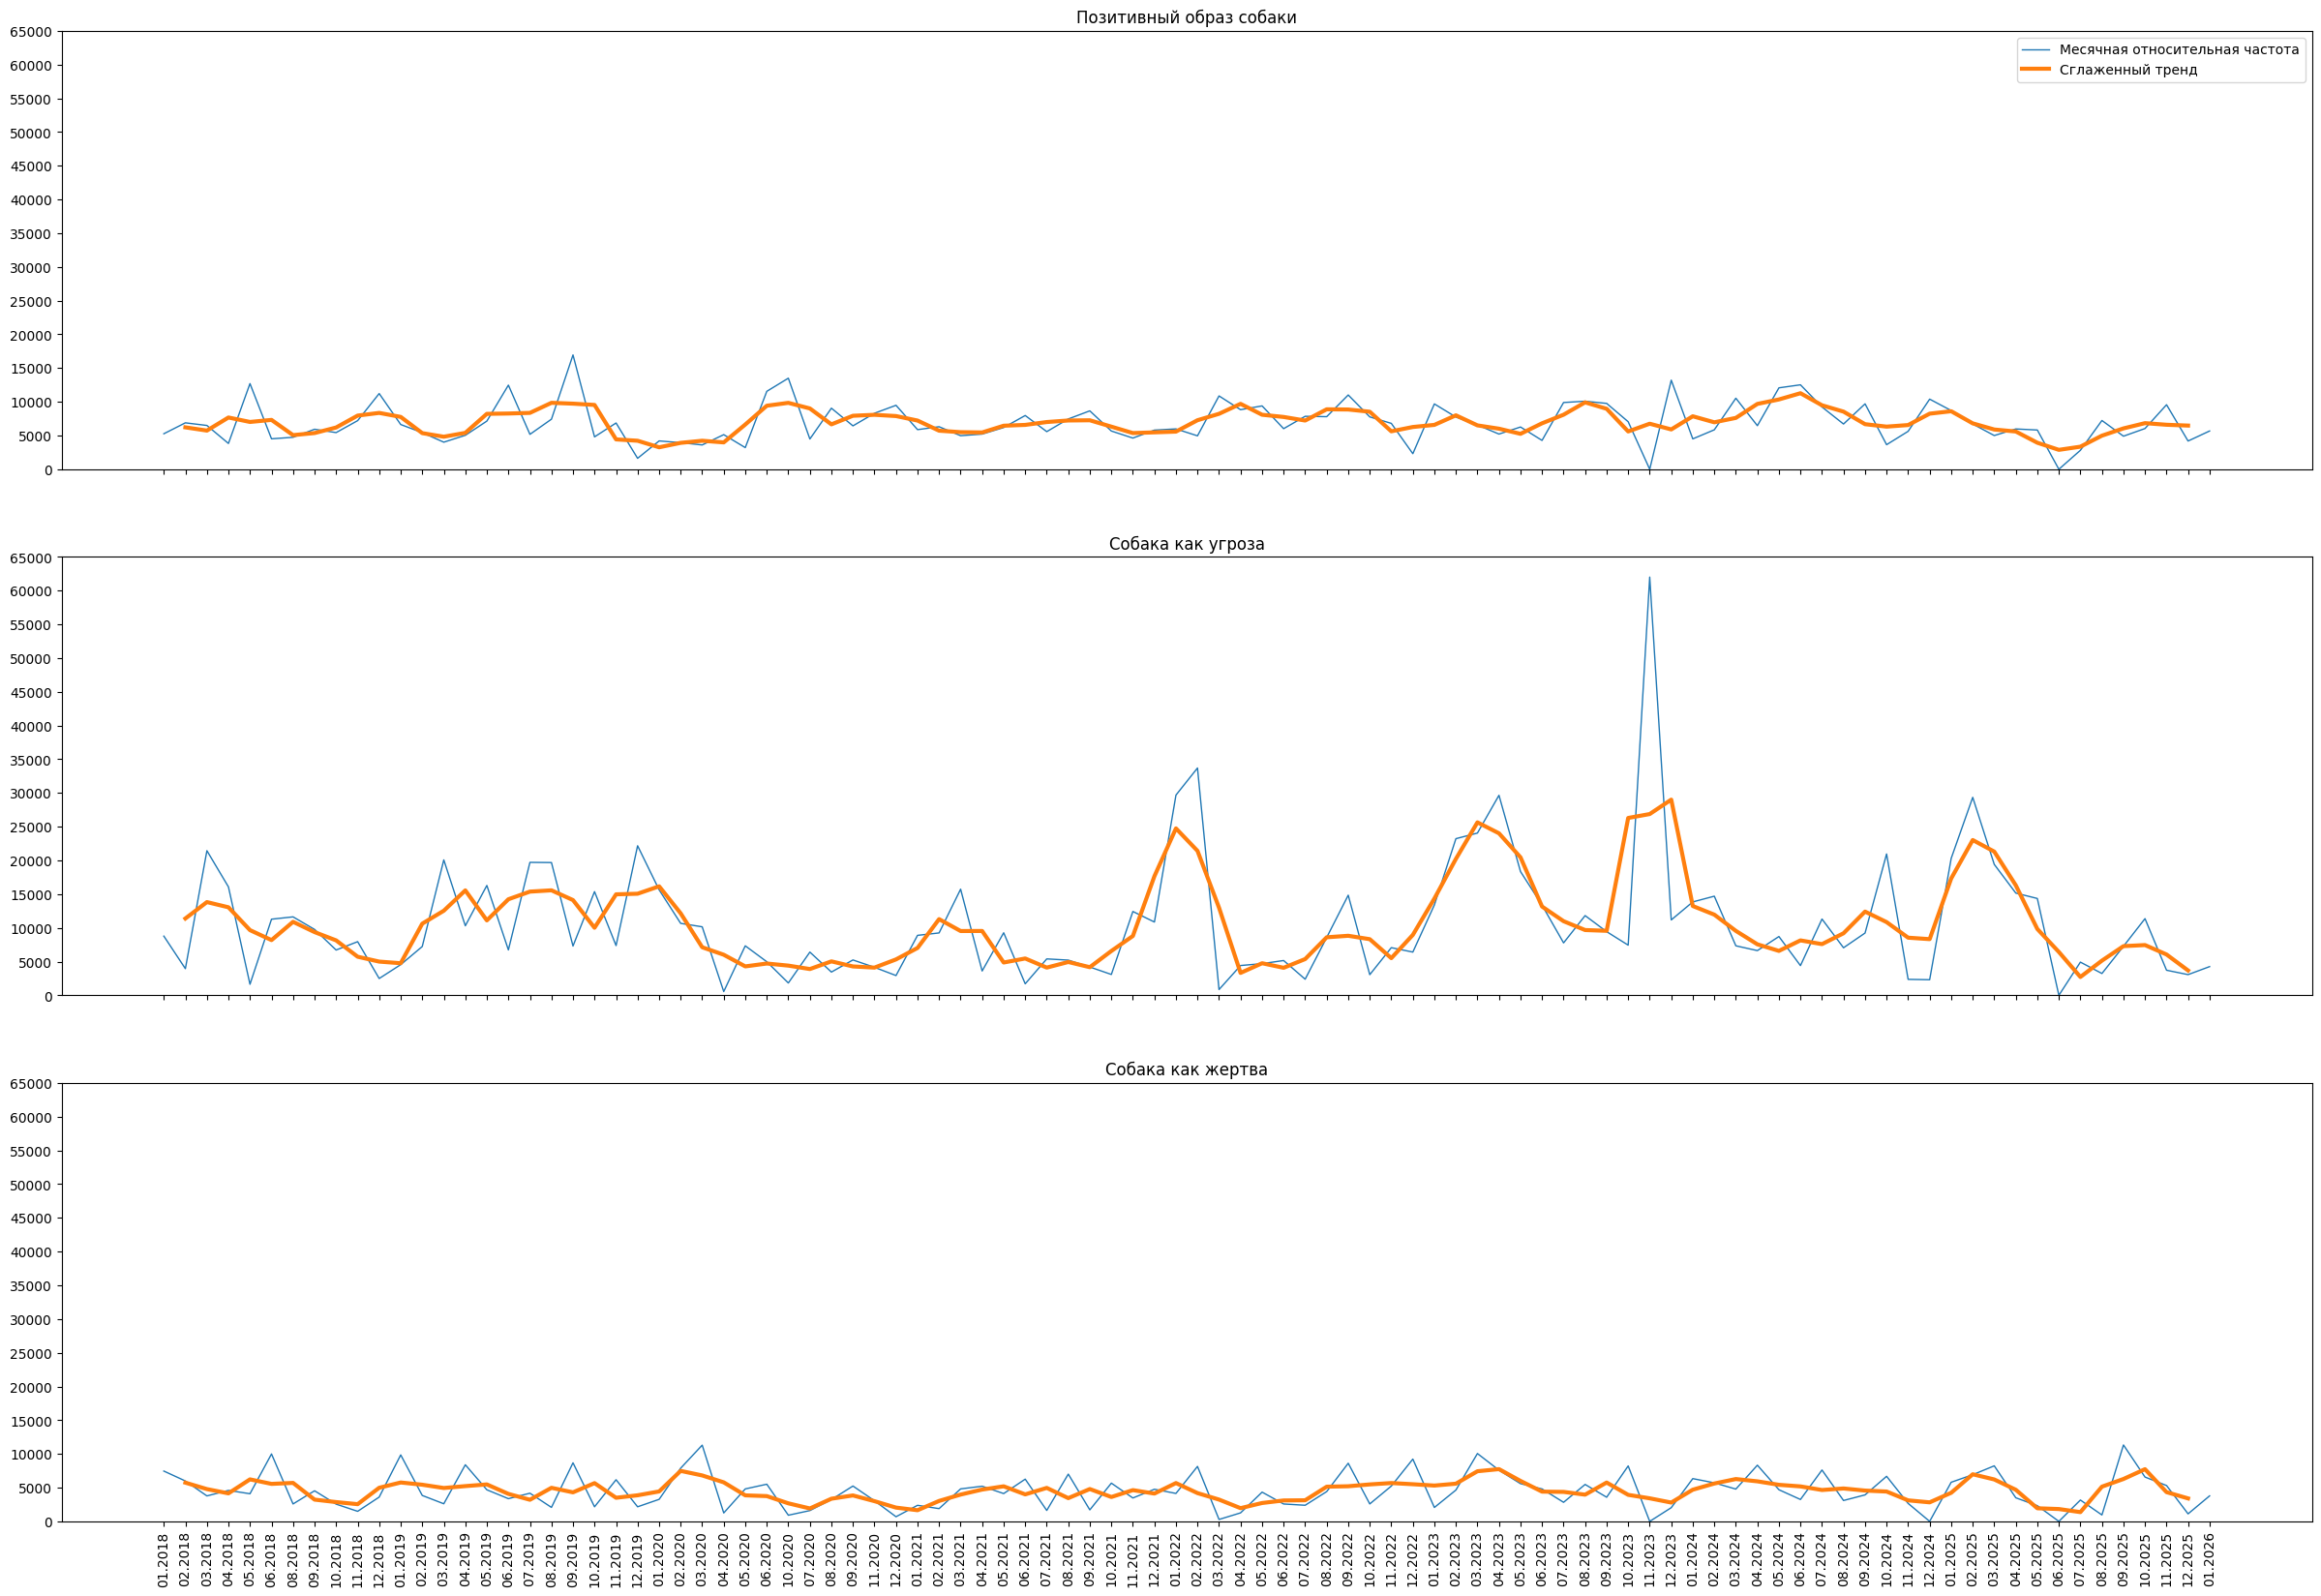

In [90]:
fig, ax = plt.subplots(3,1, figsize=(30, 20), sharex=True)

ax[0].plot(df_ria_monthly['Месяц'], df_ria_monthly['Позитив_norm'], label='Месячная относительная частота', linewidth=1)
ax[0].plot(df_ria_monthly['Месяц'], df_ria_monthly['Позитив_norm'].rolling(3,center=True).mean(), label='Сглаженный тренд', linewidth=3)
ax[0].set_title('Позитивный образ собаки')

ax[1].plot(df_ria_monthly['Месяц'], df_ria_monthly['Угроза_norm'], linewidth=1)
ax[1].plot(df_ria_monthly['Месяц'], df_ria_monthly['Угроза_norm'].rolling(3,center=True).mean(), linewidth=3)
ax[1].set_title('Собака как угроза')

ax[2].plot(df_ria_monthly['Месяц'], df_ria_monthly['Жертва_norm'], linewidth=1)
ax[2].plot(df_ria_monthly['Месяц'], df_ria_monthly['Жертва_norm'].rolling(3,center=True).mean(), linewidth=3)
ax[2].set_title('Собака как жертва')

for a in ax:
    a.yaxis.set_major_locator(ticker.MultipleLocator(5000))
    a.set_ylim(0, 65000)

plt.xticks(rotation=90)
ax[0].legend()
plt.show()

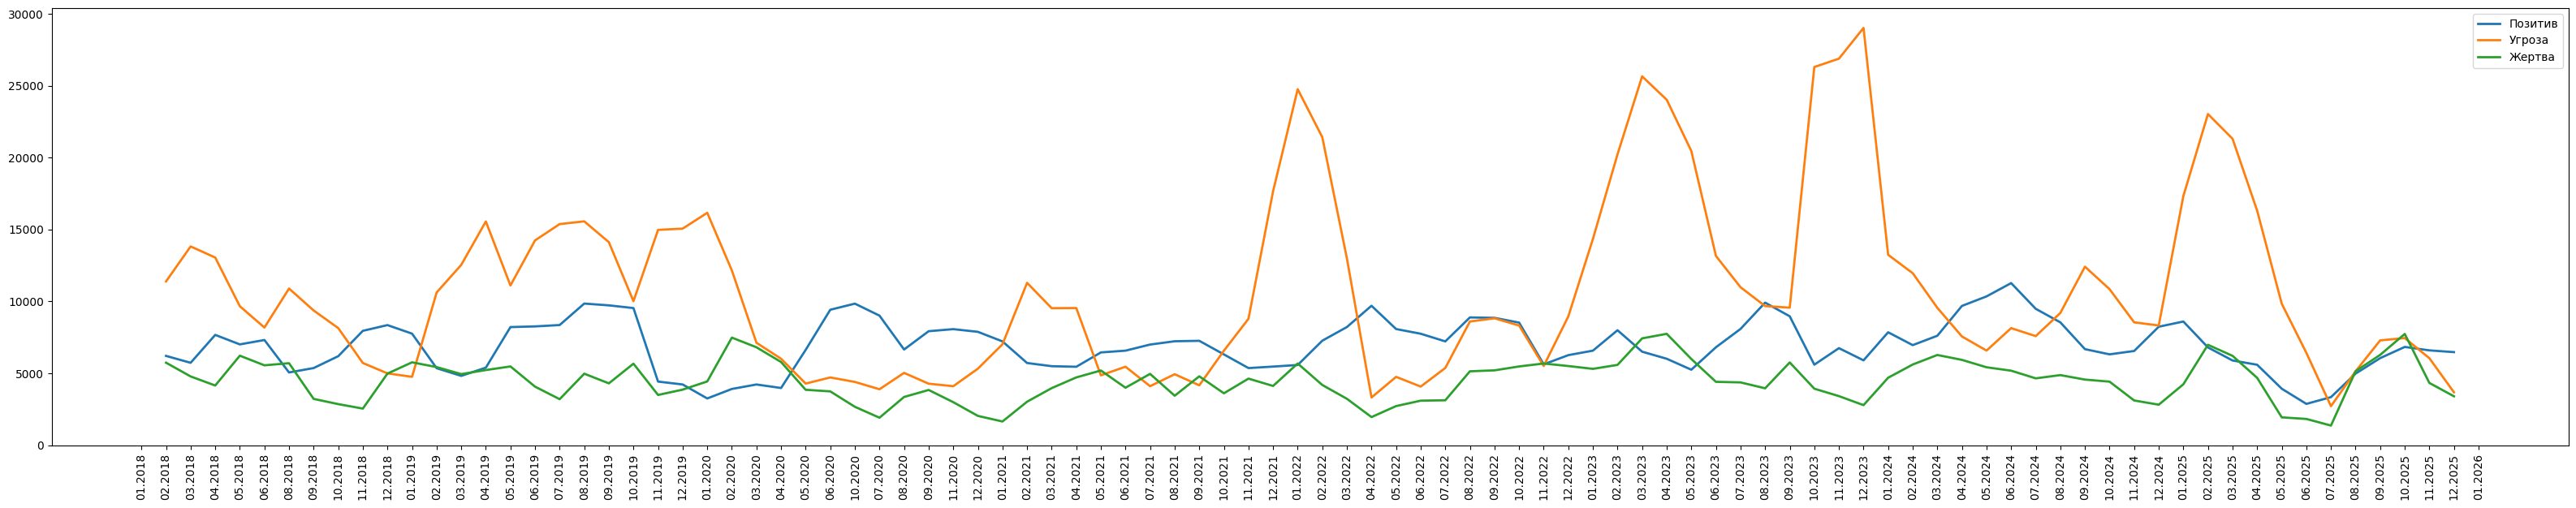

In [69]:
fig, ax = plt.subplots(figsize=(40, 7))

ax.plot(df_ria_monthly['Месяц'], df_ria_monthly['Позитив_norm'].rolling(3,center=True).mean(), label='Позитив', linewidth=2)
ax.plot(df_ria_monthly['Месяц'], df_ria_monthly['Угроза_norm'].rolling(3,center=True).mean(), label='Угроза', linewidth=2)
ax.plot(df_ria_monthly['Месяц'], df_ria_monthly['Жертва_norm'].rolling(3,center=True).mean(), label='Жертва', linewidth=2)

ax.legend()
plt.xticks(rotation=90)
plt.show()

Возвращаемся к Лента.ру

In [70]:
#смотрим, какие слова чаще всего встречаются рядом со словом "собака" или "пёс" у лента ру

keywords = {'собака', 'пёс'}
context_words = []
    
for cell in df_lenta_monthly['Биграммы']:
    for (n1, n2), freq in cell.items():
        if n1 in keywords:
            context_words.append(n2)
        elif n2 in keywords:
            context_words.append(n1)
    
result = Counter(context_words).most_common(200)        
print(result)

[('порода', 185), ('кличка', 170), ('спасти', 160), ('хозяин', 160), ('напасть', 126), ('бездомный', 120), ('владелец', 114), ('бродячий', 114), ('домашний', 104), ('слово', 90), ('хозяйка', 85), ('найти', 85), ('человек', 84), ('однако', 83), ('нападение', 75), ('служебный', 74), ('гулять', 74), ('ребёнок', 73), ('животное', 73), ('выгуливать', 73), ('приют', 71), ('прогулка', 70), ('несколько', 69), ('оказаться', 68), ('мужчина', 67), ('обнаружить', 66), ('заметить', 63), ('стая', 62), ('помочь', 60), ('улица', 59), ('маленький', 58), ('забрать', 57), ('крупный', 56), ('собака', 55), ('женщина', 54), ('вместе', 54), ('пострадать', 54), ('жить', 53), ('наброситься', 53), ('лай', 52), ('получить', 51), ('находиться', 51), ('полицейский', 50), ('кроме', 49), ('взять', 49), ('увидеть', 47), ('наслать', 46), ('поводок', 44), ('отметить', 44), ('бойцовский', 44), ('остаться', 43), ('мир', 43), ('выгул', 43), ('любимый', 43), ('оставить', 43), ('опасный', 43), ('мой', 42), ('удаться', 42), 

In [71]:
dog_positive_l = ['друг','питомец','любимый','верный','мечтать', 'завести','взять','любитель','семья','питомец','кличка','спасти','служебный','выставка',
                'прогулка','полицейский','ездовой','маленький','щенок','игра','ухаживать','замечательный','сторожевой','пастуший','поддержка','дрессировка','вилять','четвероногий',]

dog_as_threat_l = ['нападение', 'напасть','нападать','наброситься', 'загрызть', 'укусить','покусать','насмерть','рваный','агрессия',
                 'агрессивный','обезобразить', 'стая', 'опасный','безнадзорный','бойцовский','бойцовый','укус','бешеный','усыпление','умерщвление','эвтаназия']

dog_as_victim_l = ['мясо','жестокий', 'обращение', 'жестоко', 'обращаться', 'убить','убивать','убийство', 'гибель','избить','пострадать','бой',
                 'сбить','бить','избиение','отравить', 'избить','труп','мёртвый','погибнуть','пристреливать','застрелить','скончаться']


Log-likelihood

In [94]:
#собираем все леммы в один список

all_lemmas_l = []

for lemmas in df_lenta_monthly['Леммы']:
    all_lemmas_l.extend(lemmas)

len(all_lemmas_l)

467079

In [73]:
finder = BigramCollocationFinder.from_words(all_lemmas_l)

scored_lenta = finder.score_ngrams(bigram_measures.likelihood_ratio)

In [74]:
df_ll_l = pd.DataFrame(scored_lenta, columns=['bigram', 'LL'])
df_ll_lenta_clean = df_ll_l[(df_ll_l['LL'] >= 15)]

#чистим от стоп-слов
df_ll_lenta_clean = df_ll_lenta_clean[df_ll_lenta_clean['bigram'].apply(lambda x: x[0] not in stop_words_bigram and x[1] not in stop_words_bigram)]

df_ll_lenta_clean[:10]

,bigram,LL
11,"(жестокий, обращение)",2271.941500
12,"(бродячий, собака)",2225.659378
13,"(домашний, животное)",2153.764992
15,"(ветеринарный, клиника)",1792.468915
16,"(немецкий, овчарка)",1753.200349
20,"(бездомный, собака)",1482.301821
25,"(обращение, животное)",1332.557142
27,"(статья, ук)",1300.156801
30,"(стая, бродячий)",1201.189887
31,"(золотистый, ретривер)",1199.037680


In [76]:
#отбираем биграммы, содержащие слова-маркеры
df_ll_lenta_clean[df_ll_lenta_clean['bigram'].apply(lambda x: x[0] in dog_positive_l or x[1] in dog_positive_l)].to_csv('collocations_raw_pos.csv', encoding='utf-8')
df_ll_lenta_clean[df_ll_lenta_clean['bigram'].apply(lambda x: x[0] in dog_as_threat_l or x[1] in dog_as_threat_l)].to_csv('collocations_raw_threat.csv', encoding='utf-8')
df_ll_lenta_clean[df_ll_lenta_clean['bigram'].apply(lambda x: x[0] in dog_as_victim_l or x[1] in dog_as_victim_l)].to_csv('collocations_raw_victim.csv', encoding='utf-8')

In [77]:
trash_positive_l = set([
    'олимпийский','королевский','гость','рука','предать','косуля','визг','башкирия','колорадо','нужно','образец','законотворец',
    'задержать','десятка','вожатый','свинка','вырывать','кот','отпуск','кузбасс','шашка','росгвардия','многодетный','шпион','захаров','забежать',
    'рыболов','необходимо','димитрис','татарстан','футболка','усольцев','benji','ханты-мансийск','находиться','аренда','однако','связать',
    'сталлоно','жена','язык','подробность','пояснять','укусить','вариативный','повесить','нанять','кубань','загитов','бурятия','отколоться','каролина',
    'раскритиковать','балкон','компьютерный','нести','казань','они','прийтись','буквально','гражданский','дизайнер','мчс','вычислить','отдать','блеять',
    'сашнев','титовский','фестиваль','взаимоотношение','затравить','коллекция','изъять','вонок','пиццерия','вызвать','дело','окно','догги-стайла','киплинг',
    'рукоделие','трейлраннинг','раздолье','персонаж','раненый','папанов','событие','санкт-петербург','салон','ребёнок','больной','минприрода','мультфильм','сцепиться',
    'японский','выбрасывание','заложник','кузина','часто','таиланд','смерть','просьба','worker','американский','нож','знак','сахалинский','самовыгул','бывший', 'боссюэ',
    'verne','неунывающий', 'околелый','жюля','хубэя','чайяпхума','белок','лазуткин','сладков','ереванец','справиться','напасть','закат','ростов-на-дону','сериал',
    'робот','переставать','паб','иа','рискнуть','карнатака','ситуация','киршнер','кусочек','похожий','ubisoft','бойкотировать','жанровый','adventure','genshin',
    'дурачок','напёрсток','несъеденный','прищемить','сафин','смысловой','телепроект','цици','мальчик','предназначить','классик','воспринимать','выбросить','пенза',
    'сэлмона','фермер','направление','продвинуть','отдельно','питаться','поросёнок','установить','совпадение','зима','великобритания','калифорния','mann','робот-птичка',
    'издревле','рейбон','вить','норильск','мариуполь','парковать','упорство','вакцина','стоить','покинуть'
])

In [78]:
#позитив + без стоп-слов
positive_valid_bigrams_lenta = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_positive_l or bg[1] in dog_positive_l) and bg[0] not in trash_positive_l and bg[1] not in trash_positive_l))

In [79]:
trash_threat_l = set([
    'гиеновидный','затоптать','койот','дело','крокодил','кодруц','владикавказ','кодруц','особо','пума','медведь','ромбический','аллигатор',
    'клещ','утверждаться','змеиный','корова','австрийский','аллигатор','енотовидный','хищник','хамас','ядовитый','левый',
    'совершение','медведица','змея','эрина','агент','охотиться','спасти','когда-то','утверждаться','отдать','корова','леопард',
    'сбить','койот','трёхметровый','предмет','свидетель','волков','болезнь','хищник','медведь-губач','динго','лебедь','драться','чёрный'
    'дальний','медведь','рысь','ван','коммандер','ромь','человечество','пчела','трансляция','власть','кулак','объект','паразитический',
    'акула','рюкзак','кабанов','крокодил','украшение','промоушный','отказник','лебедь','коммандер','успенский','ужкх','мамайк','слесарить',
    'черкесов','провиниться','треш-блогер','блошиный','загнить','пчелиный','иксодовый','слепок','милиция','одри','бесполезно','обстрел','жестикуляция',
    'причинение','выбраковывать','несвойственный','патологически','впоследствии','годшилла','уобби','шнурок','кобра','сиб.фма','бабка','тираннозавр',
    'травмироваться','форд','привычка'
])

In [80]:
threat_valid_bigrams_lenta = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_as_threat_l or bg[1] in dog_as_threat_l)and bg[0] not in trash_threat_l and bg[1] not in trash_threat_l))

In [81]:
trash_victim_l = set([
    'никто','мать','семилетний','повлечь','мальчик','кошачий','россиянка','сильно','травма','отец','гупо','ребёнок',
    'начать','найти','обвинить','растерзать','обнаружить','гуманный','россиянин','подросток','орехово-зуево','причина',
    'преследоваться','жена','грубо','полиция','ран', 'нападение','результат','подозревать','расследование','основа',
    'вредить','удушение','омск','гладиаторский','несовершеннолетний','спасти','проучить','обвинить','гонконг','аль-багдади',
    'ук','начало','обморочный','новоуральск','ради','серьёзно','нежирный','уфа','администрация','пожар','получить','продавать',
    'помощь','куала-лумпур','едва','феникс','моржовый','кызыл','огонь','результат','продажа','алтарь','притвориться','девочка',
    'обезобразить','перетащить','искусать','говядина','многократно','таганрог','барабан','известно','травма','шахматистка',
    'случайно','крепко','захоронить','съесть','лишить','автокатастрофа','раджастхан','плохо','ангела','нагнать','помощь','они',
    'порядок','человек','обратиться','неизвестный','планировать','шампур','блюдо','консультация','опрокинуть','свежий','разгромить',
    'колония-поселение','заговор','диагностировать','коллективный','попрощаться','браконьер','родитель','екатеринбург','сосед',
    'владивосток','мука','обнаружить','останки','пламя','сын','наказание','запрещаться','причастный','испуг','мужчина','варёный','жареный',
    'приурочить','туберкулёз','искусать','мера','могила','оказать','дочь','запрет','безответственный','приклад','подозревать','найти',
    'нападение','рацион','совершенный','shamuyashe','тревога','немедленно','куриный','призыв','обнаружение','заканчиваться','распространять',
    'супруг','пенсионерка','кировск','голова','организатор','ответственность','указание','контейнер','связь','последующий','традиционно',
    'уметь','ломит','ломить','монтебелло','петушиный','помянуть','эпизоотия','слово','обочина','жирный','сомкнуть','тыкать','случайно',
    'bess','невнимательность','бетономешалка','кружиться','разложиться','задержать','производить','написать','госсекретарь','мадам',
    'четверолапый','проморолик','факт','подозревать','кашалот','пенсионер','грубый','купание','фургон','умереть','расправа','отец-инвалид',
    'сарлоса','наслать','китай','danmcclelland','нит','норвежка','хантавирусный','скоропостижно','потушить','фрикаделька','пошатываться',
    'кодекс','сотрясение','пустырь','укус','спортсменка','обращение','соответствовать','внесудебный','грейт-ярмут','киселёвск','непредумышленный',
    'воспитываться','подстрекательство','лифт','россиянин','привести','испариться','запрет','планировать','приготовить','пароход','хоуторный','челюскин',
    'мёртвый','статья','зверски','лысейко','паства','преднамеренно','ольховник','углегорскуголь','криминализировать','преподать','жилец','больница',
    'регулировать','зюзино','подруга','совершить','рекомендовать','horm','воскресить','ипра','патхумтхани','билс','покуситься','диагностировать',
    'курица','екатеринбург','землетрясение','коала','ирландец','нагорный','механика','детёныш'
])

In [82]:
victim_valid_bigrams_lenta = set(
    bg for bg in df_ll_ria_clean['bigram']
    if ((bg[0] in dog_as_victim_l or bg[1] in dog_as_victim_l)and bg[0] not in trash_victim_l and bg[1] not in trash_victim_l))

In [83]:
df_lenta_monthly['Собака_позитив'] = df_lenta_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, positive_valid_bigrams_lenta))

df_lenta_monthly['Собака_угроза'] = df_lenta_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, threat_valid_bigrams_lenta))

df_lenta_monthly['Собака_жертва'] = df_lenta_monthly['Биграммы'].apply(lambda x: total_valid_bigrams(x, victim_valid_bigrams_lenta))

In [84]:
df_lenta_monthly['Позитив_norm'] = df_lenta_monthly['Собака_позитив'] / df_lenta_monthly['Леммы'].apply(len) * 1000000
df_lenta_monthly['Угроза_norm'] = df_lenta_monthly['Собака_угроза'] / df_lenta_monthly['Леммы'].apply(len) * 1000000
df_lenta_monthly['Жертва_norm'] = df_lenta_monthly['Собака_жертва'] / df_lenta_monthly['Леммы'].apply(len) * 1000000
df_lenta_monthly.head()

,Месяц,Текст,Леммы,Абс.частоты,Биграммы,Собака_позитив,Собака_угроза,Собака_жертва,Позитив_norm,Угроза_norm,Жертва_norm
0,01.2018,вошли четыре человека со старыми ружьями и дро...,"[войти, четыре, человек, старый, ружьё, дробов...","{'войти': 1, 'четыре': 3, 'человек': 18, 'стар...","{('войти', 'четыре'): 1, ('четыре', 'человек')...",7,10,1,3134.796238,4478.280340,447.828034
1,02.2018,"стиг постоял с минуту, а потом услышал скулеж ...","[стигнуть, постоялый, минута, услышать, скулёж...","{'стигнуть': 4, 'постоялый': 1, 'минута': 2, '...","{('стигнуть', 'постоялый'): 1, ('постоялый', '...",17,11,13,4584.681769,2966.558792,3505.933118
2,03.2018,хотя внутренняя убежденность в его причастност...,"[хотя, внутренний, убеждённость, причастность,...","{'хотя': 1, 'внутренний': 1, 'убеждённость': 1...","{('хотя', 'внутренний'): 1, ('внутренний', 'уб...",12,20,7,3590.664273,5984.440455,2094.554159
3,04.2018,тогда дмитриев решил осмотреть окрестности. вы...,"[дмитриев, решить, осмотреть, окрестность, выя...","{'дмитриев': 6, 'решить': 8, 'осмотреть': 1, '...","{('дмитриев', 'решить'): 2, ('решить', 'осмотр...",13,13,8,3750.721293,3750.721293,2308.136180
4,05.2018,"«она продолжала заводиться и говорить, что я д...","[продолжать, заводиться, говорить, должный, ду...","{'продолжать': 1, 'заводиться': 1, 'говорить':...","{('продолжать', 'заводиться'): 1, ('заводиться...",25,10,3,6162.188809,2464.875524,739.462657


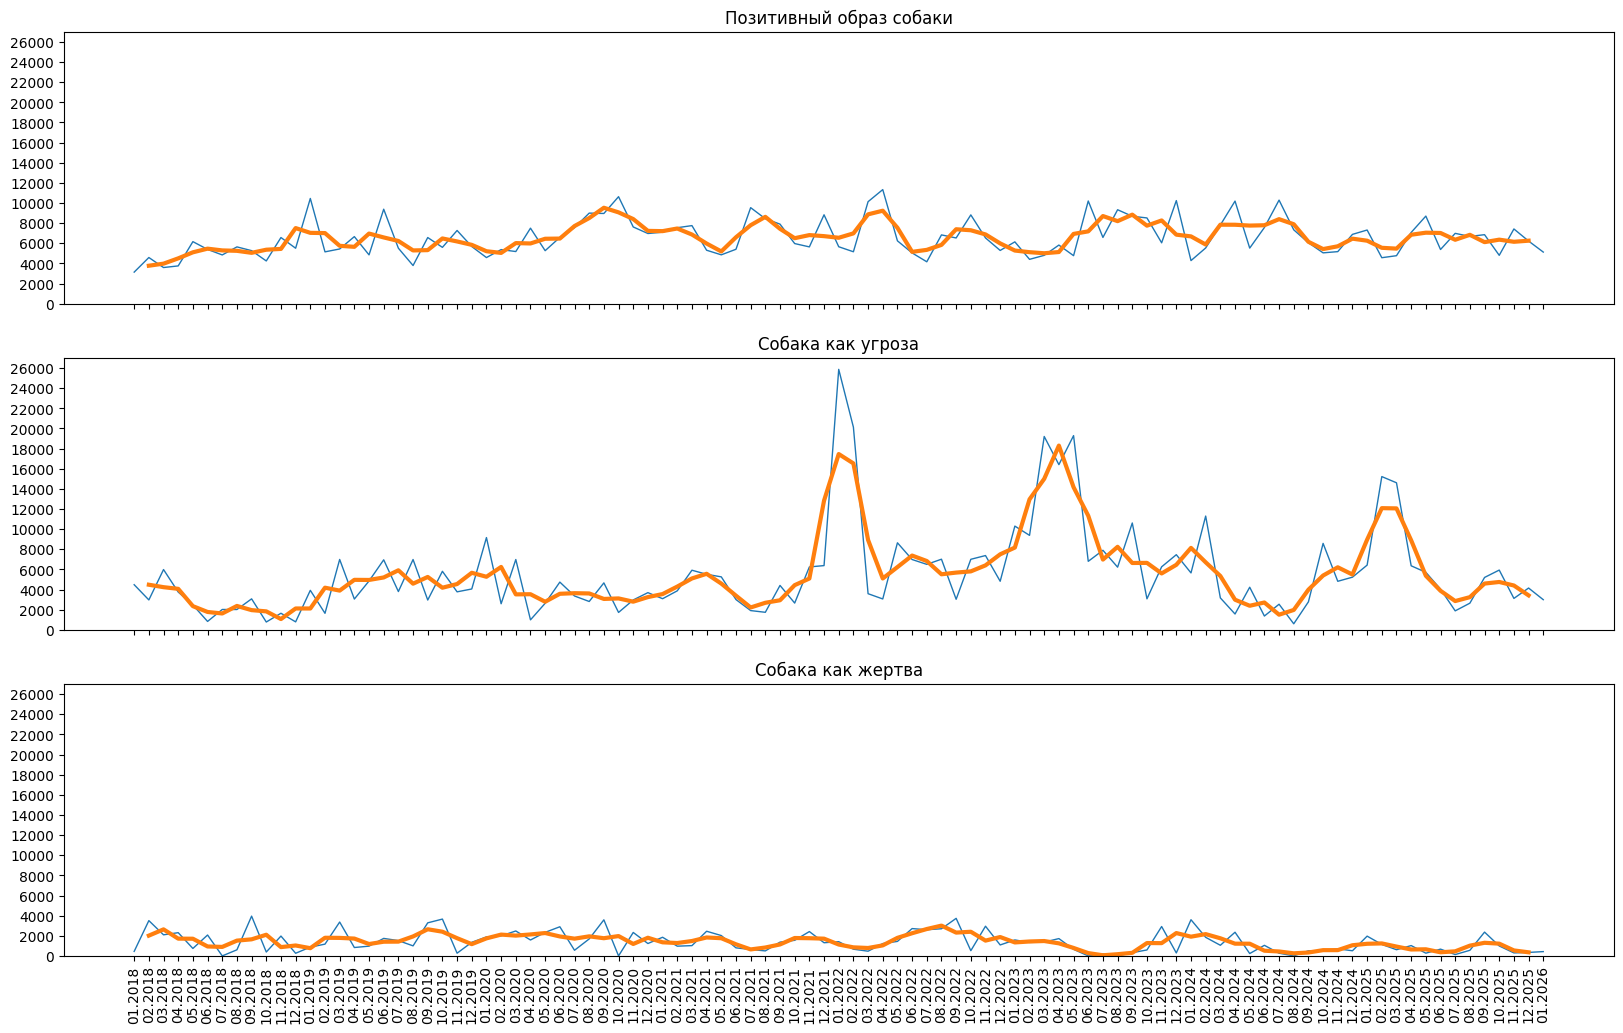

In [85]:
fig, ax = plt.subplots(3,1, figsize=(20, 12), sharex=True)

ax[0].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Позитив_norm'], linewidth=1)
ax[0].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Позитив_norm'].rolling(3,center=True).mean(), linewidth=3)
ax[0].set_title('Позитивный образ собаки')

ax[1].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Угроза_norm'], linewidth=1)
ax[1].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Угроза_norm'].rolling(3,center=True).mean(), linewidth=3)
ax[1].set_title('Собака как угроза')

ax[2].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Жертва_norm'], linewidth=1)
ax[2].plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Жертва_norm'].rolling(3,center=True).mean(), linewidth=3)
ax[2].set_title('Собака как жертва')

for a in ax:
    a.yaxis.set_major_locator(ticker.MultipleLocator(2000))
    a.set_ylim(0, 27000)

plt.xticks(rotation=90)
plt.show()

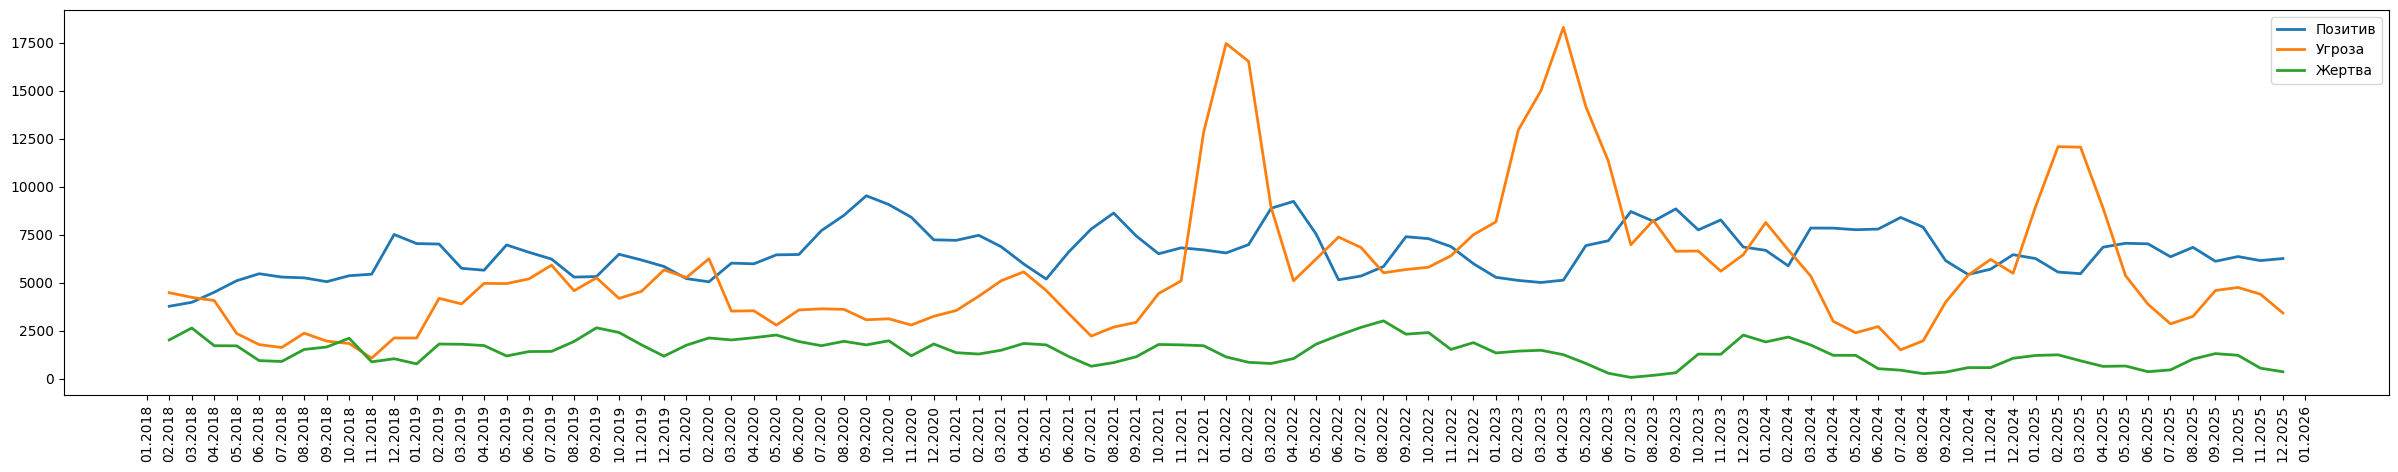

In [86]:
fig, ax = plt.subplots(figsize=(30, 5))

ax.plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Позитив_norm'].rolling(3,center=True).mean(), label='Позитив', linewidth=2)
ax.plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Угроза_norm'].rolling(3,center=True).mean(), label='Угроза', linewidth=2)
ax.plot(df_lenta_monthly['Месяц'], df_lenta_monthly['Жертва_norm'].rolling(3,center=True).mean(), label='Жертва', linewidth=2)

ax.legend()
plt.xticks(rotation=90)
plt.show()